In [1]:
# Import Libraries
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Load Dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/classification_dataset/train",
    image_size=(224, 224),
    batch_size=32,
)

validation_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/classification_dataset/valid",
    image_size=(224, 224),
    batch_size=32,
)

# store class labels 
class_names = train_ds.class_names

Found 2662 files belonging to 2 classes.
Found 442 files belonging to 2 classes.


In [3]:
# check class labels 
print(train_ds.class_names)
print(validation_ds.class_names)

['bird', 'drone']
['bird', 'drone']


Image batch shape: (32, 224, 224, 3)


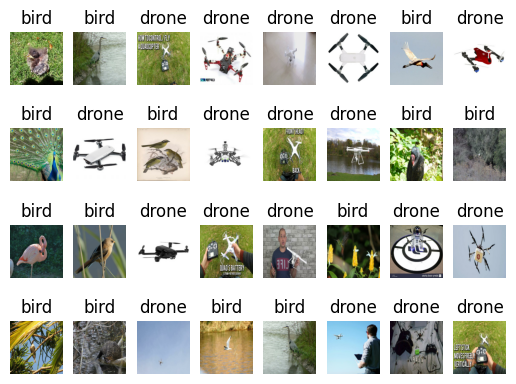

In [4]:
# visualize data
for images, labels in train_ds.take(1):
    print(f"Image batch shape: {images.shape}")
    for i in range(32):
        plt.subplot(4, 8, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [5]:
# normalize data
normalization_layer = tf.keras.layers.Rescaling(1.0 / 255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalization_layer(x), y))

In [6]:
# Data Augmentation
data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(["horizontal", "vertical"]),
        tf.keras.layers.RandomRotation(0.1),
        tf.keras.layers.RandomZoom(0.1),
    ]
)

In [7]:
# MobileNetV2 Model
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# freeze base model layers
base_model.trainable = False

# Build the model
model = models.Sequential([
    data_augmentation,          # augmentation layer
    base_model,                 # pretrained model
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid')
])

# compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [9]:
history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 783ms/step - accuracy: 0.8858 - loss: 0.2952 - val_accuracy: 0.9480 - val_loss: 0.1644
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 55s 648ms/step - accuracy: 0.9482 - loss: 0.1474 - val_accuracy: 0.9502 - val_loss: 0.1473
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 54s 639ms/step - accuracy: 0.9579 - loss: 0.1230 - val_accuracy: 0.9593 - val_loss: 0.1307
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 54s 639ms/step - accuracy: 0.9715 - loss: 0.0982 - val_accuracy: 0.9525 - val_loss: 0.1442
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 97s 820ms/step - accuracy: 0.9692 - loss: 0.0932 - val_accuracy: 0.9661 - val_loss: 0.1235
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 69s 816ms/step - accuracy: 0.9726 - loss: 0.0815 - val_accuracy: 0.9615 - val_loss: 0.1287
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 70s 669ms/step - accuracy: 0.9726 - loss: 0.0786 - val_accuracy: 0.9502 - val_loss: 0.1490
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 90s 763ms/step - accuracy: 0.9782 - loss: 0.0713 - val_accu

In [10]:
# evaluate the model
test_ds = tf.keras.utils.image_dataset_from_directory(
    "../data/classification_dataset/test",
    image_size=(224, 224),
    batch_size=32
)

test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

# get predictions
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

Found 215 files belonging to 2 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 540ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 521ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 501ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 473ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

[[119   2]
 [  6  88]]
              precision    recall  f1-score   support

        bird       0.95      0.98      0.97       121
       drone       0.98      0.94      0.96        94

    accuracy                           0.96       215
   macro avg       0.96      0.96      0.96       215
weighted avg       0.96      0.96      0.96       215



`The model performs very well overall with high accuracy. It shows excellent performance in identifying birds with minimal misclassification. However, a few drone instances are incorrectly classified as birds, indicating slightly lower recall for the drone class. This could be improved with further fine-tuning or more diverse drone data.`

In [12]:
# Custom CNN Model
custom_model = models.Sequential([
    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Flatten
    layers.Flatten(),

    # Dense Block
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

# compile the model
custom_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

d:\coding\Labmentix\Aerial-Object-Classification-Detection\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# train the model
history_custom = custom_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=10
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7002 - loss: 6.7856 - val_accuracy: 0.5882 - val_loss: 4.6924
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.7122 - loss: 1.5853 - val_accuracy: 0.4842 - val_loss: 6.7794
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 141s 2s/step - accuracy: 0.7693 - loss: 0.6868 - val_accuracy: 0.5045 - val_loss: 5.9361
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.8257 - loss: 0.4222 - val_accuracy: 0.7353 - val_loss: 1.0313
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 146s 2s/step - accuracy: 0.8460 - loss: 0.3810 - val_accuracy: 0.7398 - val_loss: 0.7015
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 201s 2s/step - accuracy: 0.8659 - loss: 0.3096 - val_accuracy: 0.7783 - val_loss: 0.5821
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 149s 2s/step - accuracy: 0.8704 - loss: 0.2974 - val_accuracy: 0.8100 - val_loss: 0.5452
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 200s 2s/step - accuracy: 0.8835 - loss: 0.2620 - val_accuracy: 0.8145 - v

In [14]:
# evaluate the model
y_true = []
y_pred_custom = []

for images, labels in test_ds:
    preds = custom_model.predict(images)
    preds = (preds > 0.5).astype(int)

    y_true.extend(labels.numpy())
    y_pred_custom.extend(preds.flatten())
    
print(confusion_matrix(y_true, y_pred_custom))
print(classification_report(y_true, y_pred_custom, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 356ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 353ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step
[[109  12]
 [ 20  74]]
              precision    recall  f1-score   support

        bird       0.84      0.90      0.87       121
       drone       0.86      0.79      0.82        94

    accuracy                           0.85       215
   macro avg       0.85      0.84      0.85       215
weighted avg       0.85      0.85      0.85       215



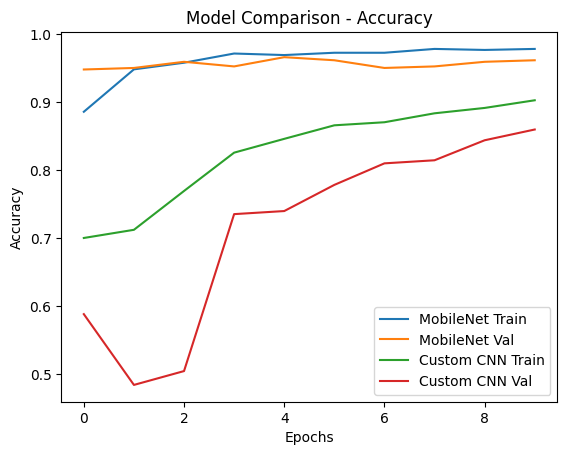

In [15]:
# Accuracy plot

plt.figure()

# MobileNet
plt.plot(history.history['accuracy'], label='MobileNet Train')
plt.plot(history.history['val_accuracy'], label='MobileNet Val')

# Custom CNN
plt.plot(history_custom.history['accuracy'], label='Custom CNN Train')
plt.plot(history_custom.history['val_accuracy'], label='Custom CNN Val')

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Model Comparison - Accuracy")
plt.show()

`The accuracy comparison between MobileNetV2 and the Custom CNN model clearly highlights the performance gap between transfer learning and training from scratch.`

`MobileNetV2 demonstrates consistently high performance, achieving training accuracy above 97% and validation accuracy around 95%. The close alignment between training and validation curves indicates strong generalization and minimal overfitting.`

`In contrast, the Custom CNN starts with significantly lower accuracy and gradually improves over epochs. While training accuracy reaches approximately 89%, validation accuracy remains lower at around 81–85%, showing a noticeable gap between training and validation performance.`

`This gap suggests that the Custom CNN is experiencing overfitting and is less capable of generalizing to unseen data compared to MobileNetV2.`

`Overall, the results indicate that transfer learning provides a substantial advantage in terms of both convergence speed and final performance.`

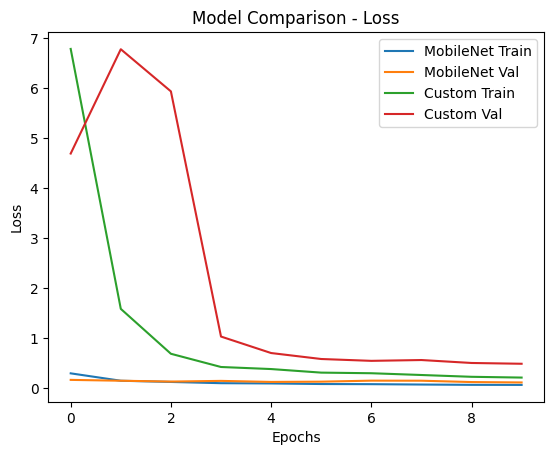

In [16]:
# Loss Plot

plt.figure()

# MobileNet
plt.plot(history.history['loss'], label='MobileNet Train')
plt.plot(history.history['val_loss'], label='MobileNet Val')

# Custom CNN
plt.plot(history_custom.history['loss'], label='Custom Train')
plt.plot(history_custom.history['val_loss'], label='Custom Val')

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Model Comparison - Loss")
plt.show()

`The loss curves further reinforce the superiority of the MobileNetV2 model over the Custom CNN.`

`MobileNetV2 shows a smooth and stable decrease in both training and validation loss, with both curves remaining closely aligned. This indicates efficient learning and good generalization without significant overfitting.`

`On the other hand, the Custom CNN exhibits a sharp drop in training loss initially, but the validation loss remains significantly higher and fluctuates across epochs. This divergence between training and validation loss is a clear indicator of overfitting.`

`Additionally, the instability in validation loss suggests that the Custom CNN struggles to learn robust and generalized features from the dataset.`

`These observations confirm that pretrained models like MobileNetV2 are more effective in extracting meaningful features, leading to better and more stable performance.`

## `Model Comparison`

### `Accuracy`
`MobileNetV2 achieved significantly higher accuracy compared to the Custom CNN. It reached approximately 97% training accuracy and 95% validation accuracy, whereas the Custom CNN achieved around 89% training accuracy and 81% validation accuracy.`

### `Training Time`
`MobileNetV2 required less training time per epoch compared to the Custom CNN. This is because MobileNetV2 leverages pretrained weights, reducing the need for extensive learning, whereas the Custom CNN learns all features from scratch, making it computationally more expensive.`

### `Generalization Performance`
`MobileNetV2 demonstrated strong generalization with a small gap between training and validation accuracy (~2%). In contrast, the Custom CNN showed a larger gap (~8%), indicating overfitting and weaker generalization capability.`

### `Conclusion`
`Overall, MobileNetV2 outperformed the Custom CNN in terms of accuracy, efficiency, and generalization. This highlights the effectiveness of transfer learning, especially when working with limited datasets.`

## `Why I Dropped the Custom CNN`

`Initially, I included a custom CNN alongside MobileNetV2 for classification. However, during deployment, the custom model (~120MB+) introduced multiple issues — slow downloads, occasional failures, and increased memory usage.`

`Since MobileNetV2 already provides strong performance with a much smaller footprint, keeping the custom CNN added unnecessary complexity without meaningful gains.`

`To keep the app lightweight, stable, and deployment-friendly, I decided to remove the custom CNN and rely on MobileNetV2 for classification, along with YOLO for detection.`

In [17]:
# save the models
model.save("../models/mobilenetv2_aerial.keras")
custom_model.save("../models/custom_cnn_aerial.keras")

In [18]:
# train YOLOv8
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="../data/detection_dataset/data.yaml",
    epochs=20,
    imgsz=416
)

Ultralytics 8.4.37  Python-3.12.1 torch-2.11.0+cpu CPU (11th Gen Intel Core i3-1115G4 @ 3.00GHz)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=../data/detection_dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001CB4E90A330>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

In [19]:
model = YOLO("../runs/detect/train/weights/best.pt")
results = model("../data/detection_dataset/test/images", show=True)


image 1/224 d:\coding\Labmentix\Aerial-Object-Classification-Detection\notebooks\..\data\detection_dataset\test\images\00083b384685315d_jpg.rf.abfd1b2cc8c681777bae66d5327bb9ea.jpg: 416x416 1 Bird, 231.4ms
image 2/224 d:\coding\Labmentix\Aerial-Object-Classification-Detection\notebooks\..\data\detection_dataset\test\images\00188d7f40a84793_jpg.rf.7f9da2b662dc236fbdcc1f22d8e0983e.jpg: 416x416 1 Bird, 161.5ms
image 3/224 d:\coding\Labmentix\Aerial-Object-Classification-Detection\notebooks\..\data\detection_dataset\test\images\0028adf0e92c3da2_jpg.rf.48c97d30547a46e83abcbd1bf801c72f.jpg: 416x416 2 Birds, 451.3ms
image 4/224 d:\coding\Labmentix\Aerial-Object-Classification-Detection\notebooks\..\data\detection_dataset\test\images\00347cbbeed4bedb_jpg.rf.aa19c9a7a22d76f8539ca12ac7cb82d5.jpg: 416x416 1 Bird, 123.6ms
image 5/224 d:\coding\Labmentix\Aerial-Object-Classification-Detection\notebooks\..\data\detection_dataset\test\images\004cc8de466969bc_jpg.rf.ca1ffa31f30a92a3987e689583983973.jp